In [3]:
import random

import torch
from matplotlib import pyplot as plt
from torch.distributions.multinomial import Multinomial

random.seed(518)
torch.manual_seed(518)

In [6]:
# Python 난수로 공정한 동전을 100번 던진다.
num_tosses = 100

heads = sum(
    random.random() > 0.5
    for _ in range(num_tosses)
)

tails = num_tosses - heads

print("Heads:", heads)
print("Tails:", tails)
print("Total:", heads + tails)

assert heads + tails == num_tosses

Heads: 47
Tails: 53
Total: 100


In [8]:
# 인덱스 0은 앞면, 인덱스 1은 뒷면의 이론적 확률이다.
fair_probabilities = torch.tensor([
    0.5,
    0.5,
])

# Multinomial
counts_100 = Multinomial(
    total_count=100,
    probs=fair_probabilities,
).sample()

frequencies_100 = counts_100 / counts_100.sum()

print("Counts:", counts_100)
print("Estimated probabilities:", frequencies_100)

Counts: tensor([53., 47.])
Estimated probabilities: tensor([0.5300, 0.4700])


In [9]:
# 표본 수를 10,000개로
counts_10000 = Multinomial(
    total_count=10_000,
    probs=fair_probabilities,
).sample()

frequencies_10000 = counts_10000 / counts_10000.sum()

print("Counts:", counts_10000)
print("Estimated probabilities:", frequencies_10000)
print(
    "Absolute head-probability error:",
    torch.abs(frequencies_10000[0] - 0.5),
)

Counts: tensor([4965., 5035.])
Estimated probabilities: tensor([0.4965, 0.5035])
Absolute head-probability error: tensor(0.0035)


In [36]:
num_experiments = 10000

individual_tosses = Multinomial(
    total_count=1,
    probs=fair_probabilities,
).sample((num_experiments,))

# 각 시점까지 앞면과 뒷면이 나온 누적 횟수를 계산한다.
cumulative_counts = individual_tosses.cumsum(dim=0)

# 각 행의 누적 전체 시행 횟수를 유지된 축 shape (10000,1)로 계산한다.
cumulative_totals = cumulative_counts.sum(
    dim=1,
    keepdim=True,
)

# 누적 발생 횟수를 누적 전체 횟수로 나누어 확률을 추정한다.
estimates = cumulative_counts / cumulative_totals

print("Individual tosses shape:", individual_tosses.shape)
print("Cumulative counts shape:", cumulative_counts.shape)
print("Estimates shape:", estimates.shape)
print("Final estimate:", estimates[-1])

Individual tosses shape: torch.Size([10000, 2])
Cumulative counts shape: torch.Size([10000, 2])
Estimates shape: torch.Size([10000, 2])
Final estimate: tensor([0.5020, 0.4980])


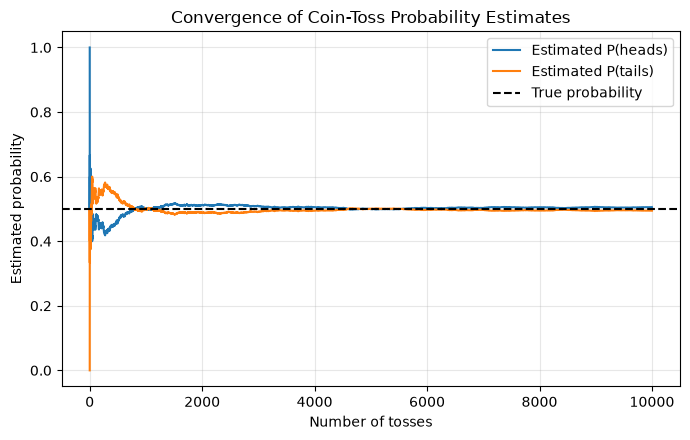

In [35]:
# 그래프 출력에는 gradient가 필요하지 않으므로 tensor를 분리해 NumPy로 변환한다.
estimates_numpy = estimates.detach().cpu().numpy()

figure, axes = plt.subplots(figsize=(7, 4.5))

axes.plot(
    estimates_numpy[:, 0],
    label="Estimated P(heads)",
)

axes.plot(
    estimates_numpy[:, 1],
    label="Estimated P(tails)",
)

# 실제 확률 0.5를 검은색 점선으로 표시한다.
axes.axhline(
    y=0.5,
    color="black",
    linestyle="--",
    label="True probability",
)

axes.set_xlabel("Number of tosses")
axes.set_ylabel("Estimated probability")
axes.set_title("Convergence of Coin-Toss Probability Estimates")
axes.grid(True, alpha=0.3)
axes.legend()

figure.tight_layout()
plt.show()